In [1]:
import cmath
import math
import numpy as np
import matplotlib.pyplot as plt
from numpy import linalg as LA

from scipy.integrate import solve_ivp
from scipy import integrate
from scipy.linalg import null_space

from scipy.optimize import fsolve
from scipy.integrate import solve_bvp
from scipy.integrate import quad_vec

from itertools import chain

from concurrent.futures import ProcessPoolExecutor

In [2]:
%matplotlib notebook

In [3]:
# length
L = 1.7

# orbital number
l = 2

# coupling srength left/right
t_L = 1
t_R = t_L

# effective mass
mx = 9

Delta = 1

In [114]:
# SOI, ZF

b_x = 0.21
b_z = 0.2

gamma_SO = 0.14

# Coulomb, backgate voltage

Ec = 0.1
Vg_min_mu = -0.4

In [5]:
phi_0 = np.linspace(0, 2*np.pi, num=31)

phi_0[0] = 0.001
phi_0[-1] -= 0.001
# phi_0[50] += 0.001

In [6]:
# Pauli z matrix, in leval-Nambu space

tau_z = np.block([[np.eye(4), np.zeros((4, 4))], [np.zeros((4, 4)), -np.eye(4)]])

In [99]:
# initializing MFA

MF_param = np.zeros((len(phi_0), 2*l))
accur_par = 6*10**(-3)
abs_diff = np.full((len(phi_0), 2*l), np.inf)

In [8]:
lambda_coupl = 0.1 # 0.1 # Andreev-continuum coupling rate
damping_param = 0.1 # 0.01
Omega = 0.01

T_ferm = 0.5
T_bos = 0.2

alpha_0 = 0.001 # 0.0001
omega_c = 1

In [9]:
def bose_distrib(x, T):
    
    if x>=0:
        n_B = 1/(np.exp(x/T)-1)
        return n_B
    else:
        n_B = 1/(np.exp(-x/T)-1)
        return -1-n_B

In [10]:
def fermi_distrib(x, T):
    return 1/(np.exp(x/T)+1)

In [11]:
# spectral density function

def spectral_density(x, lambda_coupl, alpha_0, damping_param, Omega, omega_c):
    
    J = lambda_coupl**2 * damping_param * (1/((x - Omega)**2 + damping_param**2/4) - \
                                                   1/((x + Omega)**2 + damping_param**2/4))
    
    J_ohm = alpha_0 * x * np.exp(-np.abs(x)/omega_c)
    
    return J + J_ohm

### Finding free dot eigenenergies and eigenfunctions -  hopping parameters

In [12]:
def chi_n_sigma(x, n, sigma):
    
    q = mx*gamma_SO
    k_n = n*np.pi/L
    
    cos_n = (k_n + sigma*q)/np.sqrt(2*(k_n**2 + q**2))
    sin_n = (k_n - sigma*q)/np.sqrt(2*(k_n**2 + q**2))
    
    f = np.exp(-1j*sigma*q*(x - L/2)) * (cos_n * np.exp(1j*k_n*(x-L/2)) + \
                                   sin_n * np.exp(-1j*k_n*(x-L/2)))
    
    return f/np.sqrt(L)

<IPython.core.display.Javascript object>


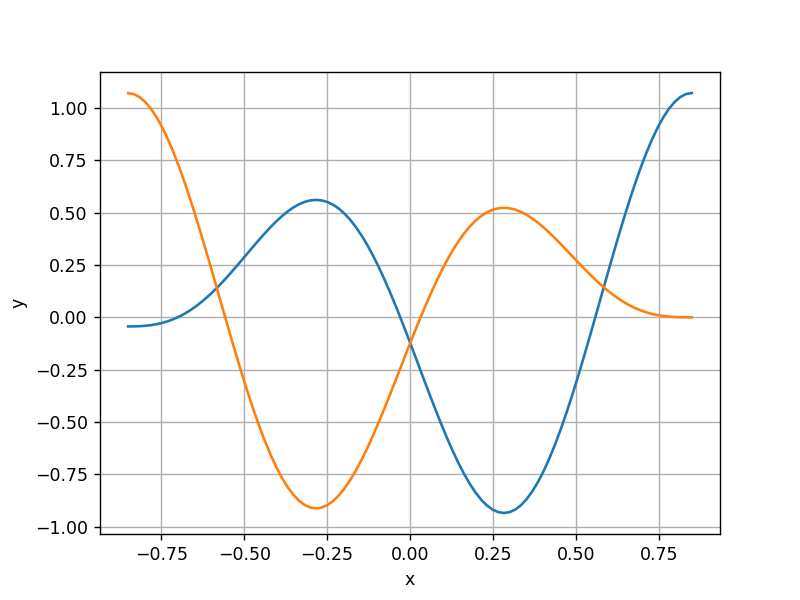

In [13]:
x_plot = np.linspace(-L/2, L/2, 100)

plt.xlabel("x")
plt.ylabel("y")



plt.plot(x_plot, np.real(chi_n_sigma(x_plot, 3, -1)))
plt.plot(x_plot, np.imag(chi_n_sigma(x_plot, 3, -1)))

plt.grid()

In [12]:
def cos_n_s(n, sigma):
    k_n = n*np.pi/L
    q = mx*gamma_SO
    
    cos_n = (k_n + sigma*q)/np.sqrt(2*(k_n**2 + q**2))
    
    return cos_n   

In [13]:
def J_mn_sigma(m, n, sigma):
    
    q = mx*gamma_SO
    k_n = n*np.pi/L
    k_m = m*np.pi/L
    
    f_s_mn = cos_n_s(n, sigma) * cos_n_s(m, -sigma) / (k_n - k_m - 2*q*sigma) -\
             cos_n_s(n, -sigma) * cos_n_s(m, sigma) / (k_n - k_m + 2*q*sigma) +\
             cos_n_s(n, sigma) * cos_n_s(m, sigma) / (k_n + k_m - 2*q*sigma) -\
             cos_n_s(n, -sigma) * cos_n_s(m, -sigma) / (k_n + k_m + 2*q*sigma)
    
    if (-1)**(n+m) == 1:
        J = 2*b_x * f_s_mn / L * (-sigma)*np.sin(q*L)
    if (-1)**(n+m) == -1:
        J = 2*b_x * f_s_mn / L * (-1j)*np.cos(q*L)
    
    return J

In [115]:
N = 20
n_arr = np.arange(1, N + 1)
q = mx*gamma_SO

k_n = n_arr * np.pi / L
eps_n = k_n**2 / (2 * mx) - mx*gamma_SO**2/2 + Vg_min_mu
m_one_arr = (-1)**n_arr

xi_n = np.sqrt(2/L) * k_n / np.sqrt(k_n**2 + (mx*gamma_SO)**2)

J_min = np.zeros((N, N), dtype='complex')
J_pl = np.zeros_like(J_min)

for n in range(N):
    for m in range(N):
        J_min[n, m] = J_mn_sigma(n+1, m+1, -1)
        J_pl[m, n] = np.conjugate(J_min[n, m])       

In [116]:
H_2 = np.zeros((2*N, 2*N), dtype='complex')

diagonal_elements = np.array([(eps + b_z, eps - b_z) for eps in eps_n]).flatten()
H_diag = np.diag(diagonal_elements)

for n in range(N):
    for m in range(N):
        H_2[2*n, 2*m+1] = J_min[n, m]
        H_2[2*n+1, 2*m] = J_pl[n, m]
        
H_2 += H_diag
E_2, Psi_2 = LA.eigh(H_2)

for i in range(2*N):
    sum_i = np.real(np.sum(Psi_2[:, i]**2))
    Psi_2[:, i] /= sum_i
    
even_rows = Psi_2[::2, :]
u = np.sum(xi_n[:, np.newaxis] * even_rows, axis=0)
# t_L_up = np.exp(1j*L*q) * np.sum(m_one_arr[:, np.newaxis] * xi_n[:, np.newaxis] * even_rows, axis=0)


odd_rows = Psi_2[1::2, :]
v = np.sum(xi_n[:, np.newaxis] * odd_rows, axis=0)
# t_L_down = np.exp(-1j*L*q) * np.sum(m_one_arr[:, np.newaxis] * xi_n[:, np.newaxis] * odd_rows, axis=0)

In [117]:
Gamma_L = np.zeros((2*l, 2*l), dtype='complex')
Gamma_R = np.zeros_like(Gamma_L)
F_R = np.zeros_like(Gamma_L)
F_L = np.zeros_like(Gamma_L)

for mu in range(4):
    for nu in range(4):
        Gamma_R[mu, nu] = np.conjugate(u[mu])*u[nu] + np.conjugate(v[mu])*v[nu]
        Gamma_L[mu, nu] = u[mu]*np.conjugate(u[nu]) + v[mu]*np.conjugate(v[nu])
    
        F_R[mu, nu] = u[mu]*v[nu] - u[nu]*v[mu]
        F_L[mu, nu] = np.conjugate(u[mu]*v[nu] - u[nu]*v[mu])  

Gamma_L *= t_L**2
Gamma_R *= t_L**2
F_L *= t_L**2
F_R *= t_L**2

### MF Hamiltonian

In [103]:
def G_inv(x, i, MF_param):
    
    s_L = 1
    s_R = -1
    zero_m = np.zeros_like(Gamma_L)
    
    
    Lambda = -1 / cmath.sqrt(Delta**2 - x**2) \
            * (x * np.block([[(Gamma_L + Gamma_R), zero_m], [zero_m, np.conjugate(Gamma_L + Gamma_R)]]) \
            - Delta * np.block([[zero_m, np.exp(-1j * s_L * phi_0[i]/2) * np.conjugate(np.transpose(F_L))], \
                                [np.exp(1j * s_L * phi_0[i]/2) * F_L, zero_m]]) \
            - Delta * np.block([[zero_m, np.exp(-1j * s_R * phi_0[i]/2) * np.conjugate(np.transpose(F_R))], \
                                [np.exp(1j * s_R * phi_0[i]/2) * F_R, zero_m]]))
    
    G_inv = x * np.eye(4*l) - np.block([[np.diag(E_2[0:2*l]) + 2*Ec*np.diag(MF_param[i]), zero_m],\
                                        [zero_m, -np.diag(E_2[0:2*l]) - 2*Ec*np.diag(MF_param[i])]]) - Lambda
    
    return LA.det(G_inv)   

In [126]:
roots = np.zeros((len(phi_0), 4*l))

for i in range(len(phi_0)):
    roots[i, 0] = fsolve(G_inv, 0.6, args=(i, MF_param))  #0.7
    roots[i, 1] = fsolve(G_inv, 0.7, args=(i, MF_param))  #0.8   
    roots[i, 2] = fsolve(G_inv, 0.8, args=(i, MF_param))  #0.9
    roots[i, 3] = fsolve(G_inv, 0.99, args=(i, MF_param))
    
    roots[i, 4] = fsolve(G_inv, -0.6, args=(i, MF_param))  
    roots[i, 5] = fsolve(G_inv, -0.7, args=(i, MF_param))     
    roots[i, 6] = fsolve(G_inv, -0.8, args=(i, MF_param))  
    roots[i, 7] = fsolve(G_inv, -0.99, args=(i, MF_param))   

<IPython.core.display.Javascript object>


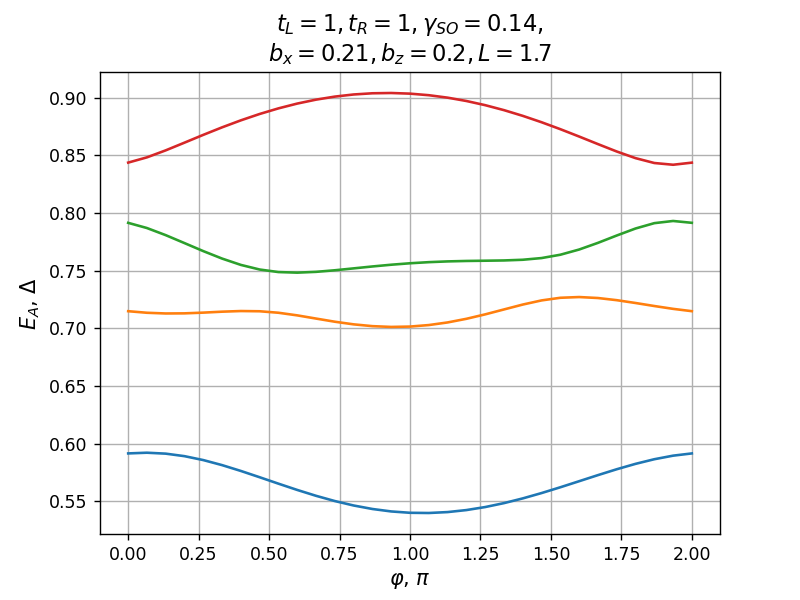

Text(0, 0.5, '$E_A$, $\\Delta$')

In [127]:
plt.plot(phi_0/np.pi, roots[:,0], linewidth=1.5)
plt.plot(phi_0/np.pi, roots[:,1], linewidth=1.5)
plt.plot(phi_0/np.pi, roots[:,2], linewidth=1.5)
plt.plot(phi_0/np.pi, roots[:,3], linewidth=1.5)


plt.title(r"$t_L={}, t_R={}, \gamma_{{SO}} = {},$"\
          .format(t_L, t_R, gamma_SO)+'\n'+
          r"$b_x={}, b_z = {}, L={}$"\
          .format(np.round(b_x, 2), np.round(b_z, 2), L), fontsize=13)



plt.grid()
plt.xlabel(r'$\varphi$, $\pi$', fontsize=12)
plt.ylabel(r'$E_A$, $\Delta$', fontsize=12)


### AL to AL transition rates

In [20]:
# diagonalizing Hamiltonian

def diagonal(x, i, MF_param):
    
    s_L = 1
    s_R = -1
    zero_m = np.zeros_like(Gamma_L)
    
    Lambda = -1 / np.sqrt(Delta**2 - x[i]**2) \
        * (x[i] * np.block([[(Gamma_L + Gamma_R), zero_m], [zero_m, (Gamma_L + Gamma_R)]]) \
        - Delta * np.block([[zero_m, np.exp(-1j * s_L * phi_0[i]/2) * np.conjugate(np.transpose(F_L))], \
                            [np.exp(1j * s_L * phi_0[i]/2) * F_L, zero_m]]) \
        - Delta * np.block([[zero_m, np.exp(-1j * s_R * phi_0[i]/2) * np.conjugate(np.transpose(F_R))], \
                            [np.exp(1j * s_R * phi_0[i]/2) * F_R, zero_m]]))


    H = np.block([[np.diag(E_2[0:2*l]) + 2*Ec*np.diag(MF_param[i]), zero_m],\
                  [zero_m, -np.diag(E_2[0:2*l]) - 2*Ec*np.diag(MF_param[i])]]) + Lambda
         
    eigval, eigvec = LA.eigh(H)
    
    return eigval, eigvec 

In [128]:
eigv_0 = np.zeros((len(phi_0), 4*l))
eigvec_0 = np.zeros((len(phi_0), 4*l, 4*l), dtype='complex')

eigv_1 = np.zeros((len(phi_0), 4*l))
eigvec_1 = np.zeros((len(phi_0), 4*l, 4*l), dtype='complex')

eigv_2 = np.zeros((len(phi_0), 4*l))
eigvec_2 = np.zeros((len(phi_0), 4*l, 4*l), dtype='complex')

eigv_3 = np.zeros((len(phi_0), 4*l))
eigvec_3 = np.zeros((len(phi_0), 4*l, 4*l), dtype='complex')

eigv_4 = np.zeros((len(phi_0), 4*l))
eigvec_4 = np.zeros((len(phi_0), 4*l, 4*l), dtype='complex')

eigv_5 = np.zeros((len(phi_0), 4*l))
eigvec_5 = np.zeros((len(phi_0), 4*l, 4*l), dtype='complex')

eigv_6 = np.zeros((len(phi_0), 4*l))
eigvec_6 = np.zeros((len(phi_0), 4*l, 4*l), dtype='complex')

eigv_7 = np.zeros((len(phi_0), 4*l))
eigvec_7 = np.zeros((len(phi_0), 4*l, 4*l), dtype='complex')

for i in range(len(phi_0)):
    
    eigv_0[i], eigvec_0[i] = diagonal(roots[:, 0], i, MF_param)
    eigv_1[i], eigvec_1[i] = diagonal(roots[:, 1], i, MF_param)
    eigv_2[i], eigvec_2[i] = diagonal(roots[:, 2], i, MF_param)
    eigv_3[i], eigvec_3[i] = diagonal(roots[:, 3], i, MF_param)

    eigv_4[i], eigvec_4[i] = diagonal(roots[:, 4], i, MF_param)
    eigv_5[i], eigvec_5[i] = diagonal(roots[:, 5], i, MF_param)
    eigv_6[i], eigvec_6[i] = diagonal(roots[:, 6], i, MF_param)
    eigv_7[i], eigvec_7[i] = diagonal(roots[:, 7], i, MF_param)

<IPython.core.display.Javascript object>


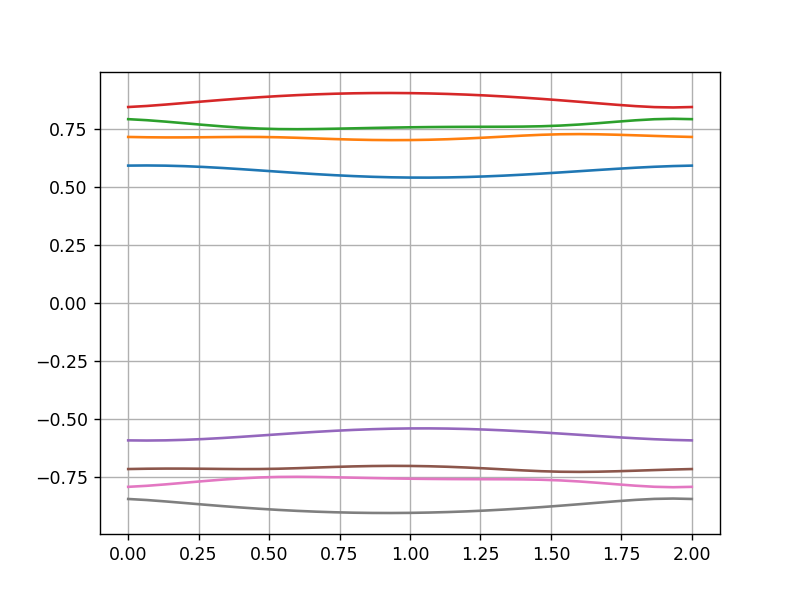

In [129]:
plt.plot(phi_0/np.pi, eigv_0[:, 4])
plt.plot(phi_0/np.pi, eigv_1[:, 5])
plt.plot(phi_0/np.pi, eigv_2[:, 6])
plt.plot(phi_0/np.pi, eigv_3[:, 7])

plt.plot(phi_0/np.pi, eigv_4[:, 3])
plt.plot(phi_0/np.pi, eigv_5[:, 2])
plt.plot(phi_0/np.pi, eigv_6[:, 1])
plt.plot(phi_0/np.pi, eigv_7[:, 0])


plt.grid()

In [130]:
# Eigenvectors corresponding to the Andreev energies

eta_0 = eigvec_0[:, :, 4]
eta_1 = eigvec_1[:, :, 5]
eta_2 = eigvec_2[:, :, 6]
eta_3 = eigvec_3[:, :, 7]

eta_4 = eigvec_4[:, :, 3]
eta_5 = eigvec_5[:, :, 2]
eta_6 = eigvec_6[:, :, 1]
eta_7 = eigvec_7[:, :, 0]

eta_arr = np.stack([eta_0, eta_1, eta_2, eta_3, eta_4, eta_5, eta_6, eta_7], axis=0)

In [131]:
# Bogoliubov transformation for the dot -> Andreev fermions 

M = np.zeros((len(phi_0), 8, 8), dtype='complex')

# Fill M[:, 0:4, :] with the conjugates of eta_0 to eta_3
M[:, 0, :] = np.conj(eta_0)
M[:, 1, :] = np.conj(eta_1)
M[:, 2, :] = np.conj(eta_2)
M[:, 3, :] = np.conj(eta_3)

# For rows 4 to 7, split and assign parts
for i, eta in enumerate([eta_0, eta_1, eta_2, eta_3]):
    M[:, 4 + i, 0:4] = eta[:, 4:]
    M[:, 4 + i, 4:] = eta[:, 0:4]
    
M_inv = LA.inv(M)
a = np.sum(np.abs(M_inv[:, 0:4, 4:])**2, axis=1)

# weight of each number of part operator n_i, i in [1, 4]
a_i = np.abs(M_inv[:, 0:4, 0:4])**2 - np.abs(M_inv[:, 4:, 0:4])**2

In [25]:
def curr_matr(x, i):
    
    s_L = 1
    s_R = -1
    zero_m = np.zeros_like(Gamma_L)
    
    Lambda_L = x * np.block([[Gamma_L , zero_m], [zero_m, Gamma_L]]) \
             - Delta * np.block([[zero_m, np.exp(-1j * s_L * phi_0[i]/2) * np.conjugate(np.transpose(F_L))], \
                                [np.exp(1j * s_L * phi_0[i]/2) * F_L, zero_m]]) 
    
    Lambda_R = x * np.block([[Gamma_R , zero_m], [zero_m, Gamma_R]]) \
             - Delta * np.block([[zero_m, np.exp(-1j * s_R * phi_0[i]/2) * np.conjugate(np.transpose(F_R))], \
                                [np.exp(1j * s_R * phi_0[i]/2) * F_R, zero_m]])
        
    I = -1 / np.sqrt(Delta**2 - x**2) / (2*1j) * (s_L * Lambda_L + s_R * Lambda_R)
    
    return I

In [26]:
def curr_nl(E_n, E_lamb, eta_n, eta_lamb, i):
            
    matr = tau_z @ curr_matr(E_lamb, i) - curr_matr(E_n, i) @ tau_z
    
    return np.conj(eta_n) @ matr @ eta_lamb    

In [132]:
I_nl = np.zeros((len(phi_0), 4*l, 4*l), dtype='complex')
G_nl = np.zeros((len(phi_0), 4*l, 4*l))

for i in range(len(phi_0)):
    for n in range(4*l):
        for lamd in range(4*l):
            I_nl[i, n ,lamd] = curr_nl(roots[i, n], roots[i, lamd], eta_arr[n, i], eta_arr[lamd, i], i)

<IPython.core.display.Javascript object>


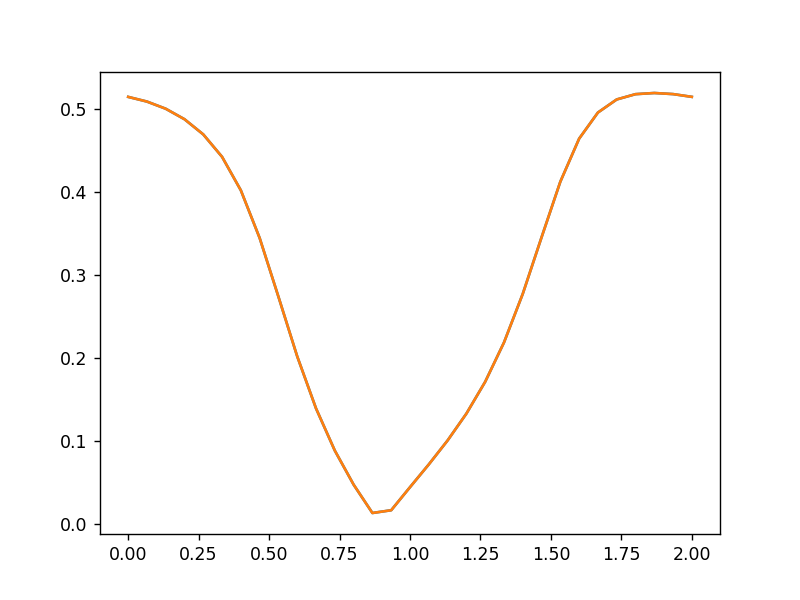

In [133]:
# plt.plot(phi_0/np.pi, np.abs(I_nl[:, 3, 2]))
# plt.plot(phi_0/np.pi, np.abs(I_nl[:, 2, 3]))

plt.plot(phi_0/np.pi, np.abs(I_nl[:, 1, 0]))
plt.plot(phi_0/np.pi, np.abs(I_nl[:, 0, 1]))

In [134]:
for i in range(len(phi_0)):
    for n in range(4*l):
        for lamd in range(4*l):
            
            energy_diff = roots[i, n] - roots[i, lamd]
            J_spect = spectral_density(energy_diff, lambda_coupl, alpha_0, damping_param, Omega, omega_c)
            bose = bose_distrib(energy_diff, T_bos)
            
            G_nl[i, lamd, n] = 2*np.pi * np.abs(I_nl[i, n, lamd])**2 * J_spect * bose 
            
            if math.isnan(G_nl[i, lamd, n]):
                G_nl[i, lamd, n] = 0

/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: divide by zero encountered in double_scalars
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/491860218.py:9: RuntimeWarning: invalid value encountered in double_scalars
  G_nl[i, lamd, n] = 2*np.pi * np.abs(I_nl[i, n, lamd])**2 * J_spect * bose


In [135]:
G_AL_pp = G_nl[:, 0:4, 0:4]
G_AL_pm = G_nl[:, 0:4, 4:8]
G_AL_mp = G_nl[:, 4:8, 0:4]

<IPython.core.display.Javascript object>


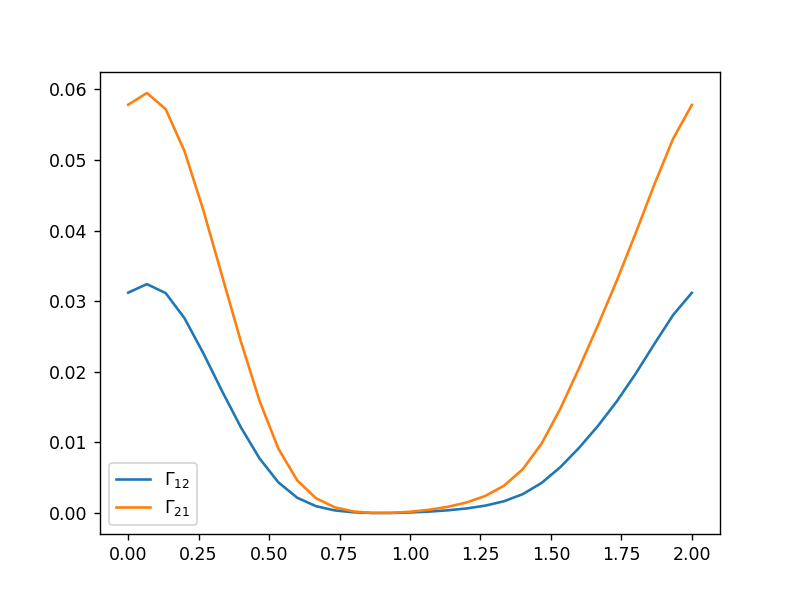

In [136]:
plt.plot(phi_0/np.pi, G_AL_pp[:, 0, 1], label=r'$\Gamma_{12}$')
plt.plot(phi_0/np.pi, G_AL_pp[:, 1, 0], label=r'$\Gamma_{21}$')

# plt.plot(phi_0/np.pi, G_AL_pm[:, 0, 2], label=r'$\Gamma_{1\bar1}$')
# plt.plot(phi_0/np.pi, G_AL_pm[:, 0, 3], label=r'$\Gamma_{1\bar2} = \Gamma_{2\bar1}$')
# plt.plot(phi_0/np.pi, G_AL_pm[:, 1, 3], label=r'$\Gamma_{2\bar2}$')

# plt.plot(phi_0/np.pi, G_AL_mp[:, 0, 2], label=r'$\Gamma_{\bar1 1}$')
# plt.plot(phi_0/np.pi, G_AL_mp[:, 0, 3], label=r'$\Gamma_{\bar1 2} = \Gamma_{\bar2 1}$')
# plt.plot(phi_0/np.pi, G_AL_mp[:, 1, 3], label=r'$\Gamma_{\bar2 2}$')


plt.legend()

### Finding transition rates ABS -> continuum: DOS

In [32]:
# DOS matrix

def spectr(x, i, MF_param):
    
    eigval_arr = np.zeros((8))
    eigvec_arr = np.zeros((8, 8), dtype='complex')
    
    s_L = 1
    s_R = -1
    zero_m = np.zeros_like(Gamma_L)
    
    Lambda = 1 / np.sqrt(x**2 - Delta**2) \
        * (x * np.block([[(Gamma_L + Gamma_R), zero_m], [zero_m, (Gamma_L + Gamma_R)]]) \
        - Delta * np.block([[zero_m, np.exp(-1j * s_L * phi_0[i]/2) * np.conjugate(np.transpose(F_L))], \
                                [np.exp(1j * s_L * phi_0[i]/2) * F_L, zero_m]]) \
        - Delta * np.block([[zero_m, np.exp(-1j * s_R * phi_0[i]/2) * np.conjugate(np.transpose(F_R))], \
                                [np.exp(1j * s_R * phi_0[i]/2) * F_R, zero_m]]))

    G_R = LA.inv(x * np.eye(8) - np.block([[np.diag(E_2[0:4]) + 2*Ec*np.diag(MF_param[i]), zero_m],\
                                           [zero_m, -np.diag(E_2[0:4]) - 2*Ec*np.diag(MF_param[i])]]) \
          + 1j * np.sign(x) * Lambda)

    G_A = np.transpose(np.conj(G_R))

    Spectr = 1j * (G_R - G_A)

    eigval_arr, eigvec_arr = LA.eigh(Spectr)
    
    return eigval_arr, eigvec_arr    

In [33]:
eigv_c = np.zeros((len(phi_0), 8))
eigvect_c = np.zeros((len(phi_0), 8, 8), dtype='complex')

for i in range(len(phi_0)):
    eigv_c[i], eigvect_c[i] = spectr(1.1, i, MF_param)

<IPython.core.display.Javascript object>


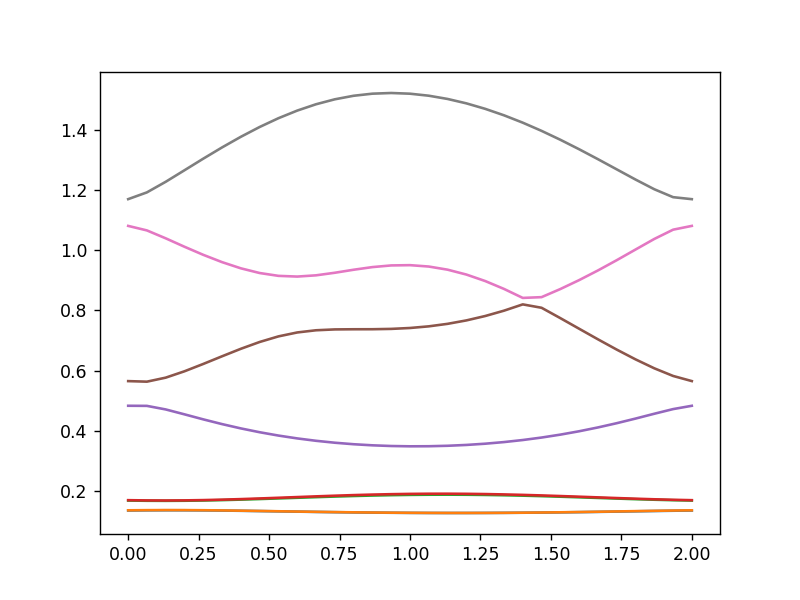

In [34]:
plt.plot(phi_0/np.pi, eigv_c[:, 0])
plt.plot(phi_0/np.pi, eigv_c[:, 1])
plt.plot(phi_0/np.pi, eigv_c[:, 2])
plt.plot(phi_0/np.pi, eigv_c[:, 3])

plt.plot(phi_0/np.pi, eigv_c[:, 4])
plt.plot(phi_0/np.pi, eigv_c[:, 5])
plt.plot(phi_0/np.pi, eigv_c[:, 6])
plt.plot(phi_0/np.pi, eigv_c[:, 7])

<IPython.core.display.Javascript object>


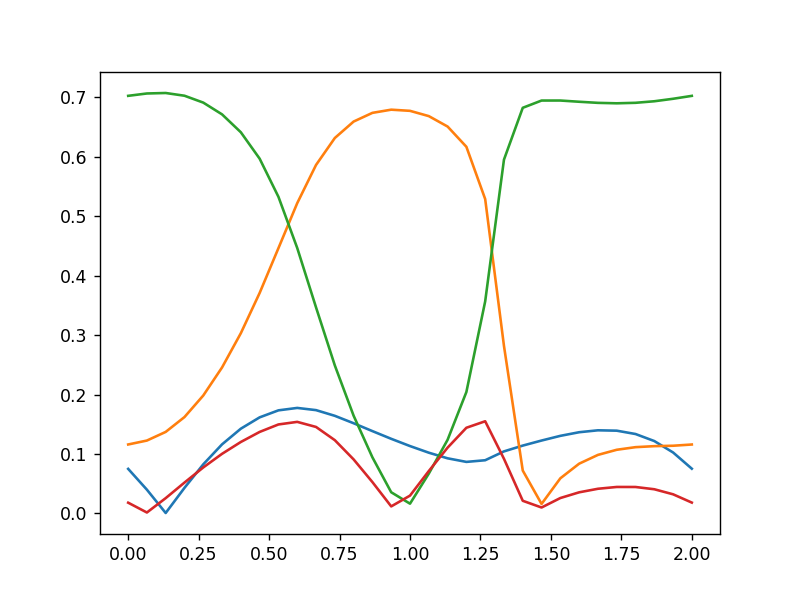

In [35]:
plt.plot(phi_0/np.pi, np.abs(eigvect_c[:, 0, 0]))
plt.plot(phi_0/np.pi, np.abs(eigvect_c[:, 1, 0]))
plt.plot(phi_0/np.pi, np.abs(eigvect_c[:, 2, 0]))
plt.plot(phi_0/np.pi, np.abs(eigvect_c[:, 3, 0]))

<IPython.core.display.Javascript object>


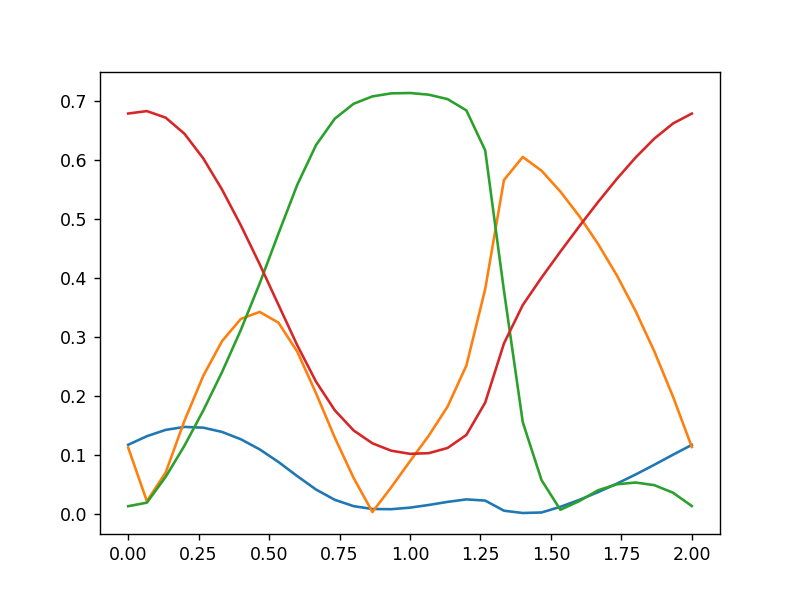

In [38]:
plt.plot(phi_0/np.pi, np.abs(eigvect_c[:, 4, 0]))
plt.plot(phi_0/np.pi, np.abs(eigvect_c[:, 5, 0]))
plt.plot(phi_0/np.pi, np.abs(eigvect_c[:, 6, 0]))
plt.plot(phi_0/np.pi, np.abs(eigvect_c[:, 7, 0]))

In [36]:
# current matrix for continuum states E > Delta - retarded square root in the denominator

def curr_matr_cont(x, i):
    
    s_L = 1
    s_R = -1
    zero_m = np.zeros_like(Gamma_L)
    
    Lambda_L = x * np.block([[Gamma_L , zero_m], [zero_m, Gamma_L]]) \
             - Delta * np.block([[zero_m, np.exp(-1j * s_L * phi_0[i]/2) * np.conjugate(np.transpose(F_L))], \
                                [np.exp(1j * s_L * phi_0[i]/2) * F_L, zero_m]]) 
    
    Lambda_R = x * np.block([[Gamma_R , zero_m], [zero_m, Gamma_R]]) \
         - Delta * np.block([[zero_m, np.exp(-1j * s_R * phi_0[i]/2) * np.conjugate(np.transpose(F_R))], \
                                [np.exp(1j * s_R * phi_0[i]/2) * F_R, zero_m]])
    
    I = -1 / (-1j * np.sign(x) * np.sqrt(x**2 - Delta**2)) / (2*1j) \
        * (s_L * Lambda_L + s_R * Lambda_R)
    
    return I

In [37]:
# continuum current matrix element

def curr_cont_nl(E, E_lamd, psi_n, eta_lamd, i):
        
    matr = tau_z @ curr_matr(E_lamd, i) - curr_matr_cont(E, i) @ tau_z
    
    return np.conj(psi_n) @ matr @ eta_lamd    

In [38]:
def integr_gamma_out(x, E_lamd, eta_lamd, i, T_bos, T_ferm,\
                    lambda_coupl, alpha_0, damping_param, Omega, omega_c):
    
    E = x + E_lamd
    
    # 8 eigenvalues, eigenvectors for continuum state
    eigv_E, eigvect_E = spectr(E, i, MF_param)
    
    # current elements
    I_nl = np.zeros((8), dtype='complex')
    
    for n in range(8): 
        I_nl = curr_cont_nl(E, E_lamd, eigvect_E[:, n], eta_lamd, i)
        
    sum_n = np.sum(eigv_E * np.abs(I_nl)**2)
    
    n_F = fermi_distrib(E, T_ferm)
    n_B = bose_distrib(x, T_bos)
    J_sp = spectral_density(x, lambda_coupl, alpha_0, damping_param, Omega, omega_c)
    
    return J_sp * n_B * (1 - n_F) * sum_n 
    

In [39]:
def integr_gamma_in(x, E_lamd, eta_lamd, i, T_bos, T_ferm,\
                    lambda_coupl, alpha_0, damping_param, Omega, omega_c):
    
    E = x + E_lamd
    
    # 8 eigenvalues, eigenvectors for continuum state
    eigv_E, eigvect_E = spectr(E, i, MF_param)
    
    # current elements
    I_nl = np.zeros((8), dtype='complex')
    
    for n in range(8): 
        I_nl = curr_cont_nl(E, E_lamd, eigvect_E[:, n], eta_lamd, i)
        
    sum_n = np.sum(eigv_E * np.abs(I_nl)**2)
    
    n_F = fermi_distrib(E, T_ferm)
    n_B = bose_distrib(x, T_bos)
    J_sp = spectral_density(x, lambda_coupl, alpha_0, damping_param, Omega, omega_c)
    
    return J_sp * (n_B + 1) * n_F * sum_n 
    

In [40]:
def compute_integrals(idx, i, lamd, Delta, T_bos, T_ferm,\
                    lambda_coupl, alpha_0, damping_param, Omega, omega_c):
    
    Gamma_out_pc = integrate.quad(integr_gamma_out, Delta - roots[i, lamd], np.infty,
                                  args=(roots[i, lamd], eta_arr[lamd, idx], i, T_bos, T_ferm,\
                    lambda_coupl, alpha_0, damping_param, Omega, omega_c))[0]
    
    Gamma_out_mc = integrate.quad(integr_gamma_out, -np.infty, -Delta - roots[i, lamd],
                                  args=(roots[i, lamd], eta_arr[lamd, idx], i, T_bos, T_ferm,\
                    lambda_coupl, alpha_0, damping_param, Omega, omega_c))[0]
    
    Gamma_in_pc = integrate.quad(integr_gamma_in, Delta - roots[i, lamd], np.infty,
                                 args=(roots[i, lamd], eta_arr[lamd, idx], i, T_bos, T_ferm,\
                    lambda_coupl, alpha_0, damping_param, Omega, omega_c))[0]
    
    Gamma_in_mc = integrate.quad(integr_gamma_in, -np.infty, -Delta - roots[i, lamd],
                                 args=(roots[i, lamd], eta_arr[lamd, idx], i, T_bos, T_ferm,\
                    lambda_coupl, alpha_0, damping_param, Omega, omega_c))[0]
    
    # Return results as a tuple
    return (idx, lamd, Gamma_out_pc, Gamma_out_mc, Gamma_in_pc, Gamma_in_mc)

In [45]:
Gamma_out_pc = np.zeros((len(phi_0), 4))
Gamma_out_mc = np.zeros_like(Gamma_out_pc) 
Gamma_in_pc = np.zeros_like(Gamma_out_pc)
Gamma_in_mc = np.zeros_like(Gamma_out_pc)

# Use ProcessPoolExecutor for parallel execution
with ProcessPoolExecutor() as executor:
    
    # Create a list of futures by submitting tasks for parallel execution
    futures = [executor.submit(compute_integrals, idx, i, lamd, Delta, T_bos, T_ferm,\
                    lambda_coupl, alpha_0, damping_param, Omega, omega_c)
               for idx, i in enumerate(range(len(phi_0))) for lamd in range(4)]
    
    # Collect results as they are completed
    for future in futures:
        i, lamd, out_pc, out_mc, in_pc, in_mc = future.result()
        
        # Store results in the appropriate arrays
        Gamma_out_pc[i, lamd] = out_pc
        Gamma_out_mc[i, lamd] = out_mc
        Gamma_in_pc[i, lamd] = in_pc
        Gamma_in_mc[i, lamd] = in_mc

/tmp/ipykernel_36930/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_36930/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_36930/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_36930/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_36930/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_36930/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_36930/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_36930/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_36930/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_36930/4160190

In [46]:
Gamma_in = (Gamma_in_pc + Gamma_in_mc) * 2*np.pi
Gamma_out = (Gamma_out_pc + Gamma_out_mc) * 2*np.pi

<IPython.core.display.Javascript object>


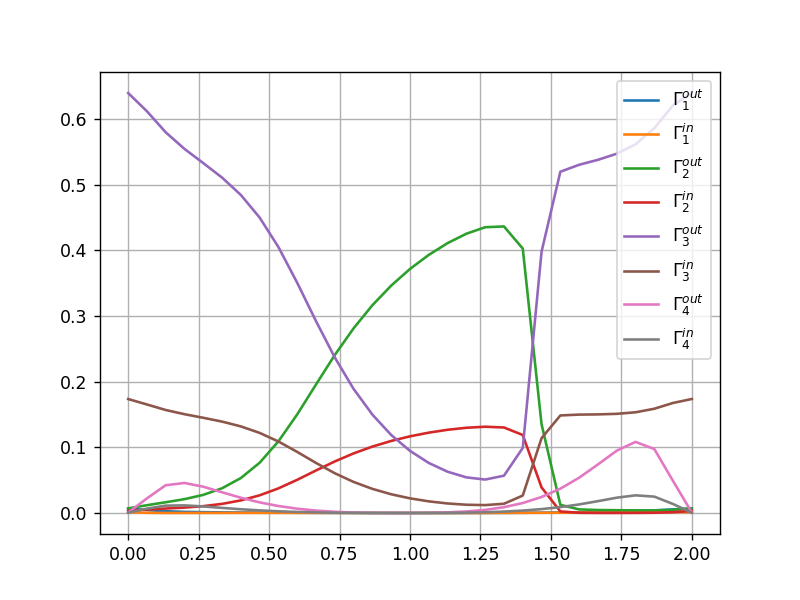

In [47]:
for i in range(Gamma_out.shape[1]):
    plt.plot(phi_0/np.pi, Gamma_out[:, i], label=rf'$\Gamma^{{out}}_{{{i+1}}}$')
    plt.plot(phi_0/np.pi, Gamma_in[:, i], label=rf'$\Gamma^{{in}}_{{{i+1}}}$')

plt.legend()
plt.grid()

## Lindblad equation: steady state

In [41]:
N = 4
N_state = 2**N

In [47]:
# function that returns the momentum state (as string) for printing

def print_state(n):
    
    if len(bin(n)[:1:-1]) < N:
        new_bin = bin(n)[:1:-1]
        for i in range(N - len(bin(n)[:1:-1])):
            new_bin += '0'
            
        return new_bin
    else:
        return bin(n)[:1:-1]

In [48]:
# the momentum vectors < q_i0 ... q_iNk | rho | q_j0 ... q_jNk >, where q's can be either 0 or 1 
# in case of fermions - by writing each i and j of the density matrix in the binary representation
# we get all possible combinations of occupied/non-occupied Nk momentum states

# this function finds whether the q'_iq entry (q = [0, Nk-1] index of the entry in the vector) is occupied or not 
def n(q, i):
    if q > len(bin(i)[:1:-1])-1:
        return 0
    else:
        return int(bin(i)[:1:-1][q])

In [49]:
lvl = np.array(range(N))
states = np.array(range(N_state))

n_v = np.vectorize(n)

nf_h = np.array([n_v(lvl, si) for si in states])

In [52]:
# steady state
Steady_M = np.zeros((len(phi_0), N_state, N_state), dtype='float64') 

for j in range(len(phi_0)):
    
    # loop over the raws - as many as there are states - 16
    for i in range(N_state):

        # loop over 4 levels
        for mu in range(4):

            n_mu = nf_h[i, mu]

            # G_in
            Steady_M[j, i, i + (-1)**n_mu * 2**mu] += n_mu * (Gamma_in[j, mu] )

            # G_out
            Steady_M[j, i, i + (-1)**n_mu * 2**mu] += (1-n_mu) * (Gamma_out[j, mu] )

            # G_in, G_out
            Steady_M[j, i, i] -= n_mu * (Gamma_out[j, mu]) + \
                                (1-n_mu) * (Gamma_in[j, mu] )

    #             loop over lambda' != lamda
            for nu in chain(range(mu), range(mu+1, 4)):

                n_nu = nf_h[i, nu]

                Steady_M[j, i, i + (-1)**n_mu * 2**mu + (-1)**n_nu * 2**nu] += \
                                n_mu * (1-n_nu) * G_AL_pp[j, nu, mu] + \
                                n_mu * n_nu * G_AL_mp[j, nu, mu] + \
                                (1-n_mu) * (1-n_nu) * G_AL_pm[j, nu, mu]

                Steady_M[j, i, i] -= (1-n_mu) * n_nu * G_AL_pp[j, nu, mu] + \
                                         (1-n_mu) * (1-n_nu) * G_AL_mp[j, nu, mu] +\
                                         n_mu * n_nu * G_AL_pm[j, nu, mu]


In [53]:
ns = np.zeros((len(phi_0), 16), dtype='float64')

for i in range(len(phi_0)):
    ns[i] = null_space(Steady_M[i], rcond=10e-16)[:,0]
#     print(i, LA.matrix_rank(Steady_M[i]))
      
steady_occup = ns
steady_occup /= np.sum(steady_occup, axis=1, keepdims=True)

In [54]:
for i in range(N_state):
    print(nf_h[i], '\t', steady_occup[25, i])

[0 0 0 0] 	 0.43026911259318323
[1 0 0 0] 	 0.1288323653489168
[0 1 0 0] 	 0.07856794474036306
[1 1 0 0] 	 0.023696331672862742
[0 0 1 0] 	 0.11311415391920432
[1 0 1 0] 	 0.031164184683551522
[0 1 1 0] 	 0.018313309170470884
[1 1 1 0] 	 0.005133652123756751
[0 0 0 1] 	 0.09282069813692036
[1 0 0 1] 	 0.02528208261954575
[0 1 0 1] 	 0.014475055602726173
[1 1 0 1] 	 0.004005936139733714
[0 0 1 1] 	 0.024193755413589986
[1 0 1 1] 	 0.006032600668393674
[0 1 1 1] 	 0.003261498626602802
[1 1 1 1] 	 0.0008373185401781699


<IPython.core.display.Javascript object>


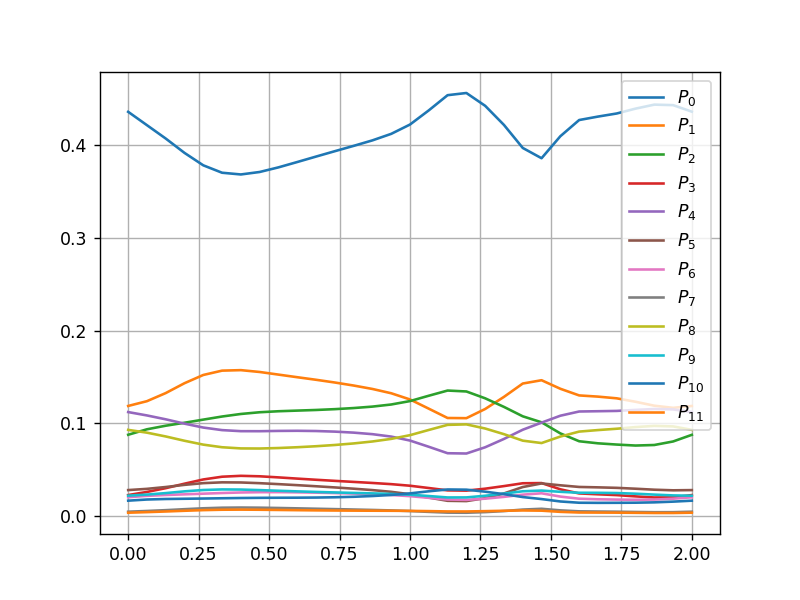

In [55]:
plt.plot(phi_0/np.pi, steady_occup[:, 0], label=r'$P_0$')
plt.plot(phi_0/np.pi, steady_occup[:, 1], label=r'$P_1$')
plt.plot(phi_0/np.pi, steady_occup[:, 2], label=r'$P_2$')
plt.plot(phi_0/np.pi, steady_occup[:, 3], label=r'$P_3$')
plt.plot(phi_0/np.pi, steady_occup[:, 4], label=r'$P_4$')
plt.plot(phi_0/np.pi, steady_occup[:, 5], label=r'$P_5$')
plt.plot(phi_0/np.pi, steady_occup[:, 6], label=r'$P_6$')
plt.plot(phi_0/np.pi, steady_occup[:, 7], label=r'$P_7$')
plt.plot(phi_0/np.pi, steady_occup[:, 8], label=r'$P_8$')
plt.plot(phi_0/np.pi, steady_occup[:, 9], label=r'$P_9$')
plt.plot(phi_0/np.pi, steady_occup[:, 10], label=r'$P_{10}$')
plt.plot(phi_0/np.pi, steady_occup[:, 11], label=r'$P_{11}$')
# plt.plot(phi_0/np.pi, steady_occup[:, 12], label=r'$P_{12}$')
# plt.plot(phi_0/np.pi, steady_occup[:, 13], label=r'$P_{13}$')

plt.grid()
plt.legend()

### Updating MF_param

In [56]:
# weight = np.zeros((len(phi_0), 4, N_state))

# for i in range(len(phi_0)):
#     for j in range(2*l):
#         for k in range(N_state):
#             weight[i, j, k] = np.sum(nf_h[k, :] * a_i[i, j, :]) # fix the raw (lambda), sum over columns

weight = np.einsum('km,ijm->ijk', nf_h, a_i)
n_lambd = np.sum(weight * steady_occup[:, None, :], axis=2) + a

# X_matr = np.zeros((len(phi_0), 2*l, 2*l))

# for i in range(len(phi_0)):
#     for k in range(2*l):
#         for m in range(2*l):
#             X_matr[i, k, m] = n_lambd[i, k] - n_lambd[i, m]

X_matr = n_lambd[:, :, None] - n_lambd[:, None, :]
MF_param_new = np.sum(X_matr, axis=1)

<IPython.core.display.Javascript object>


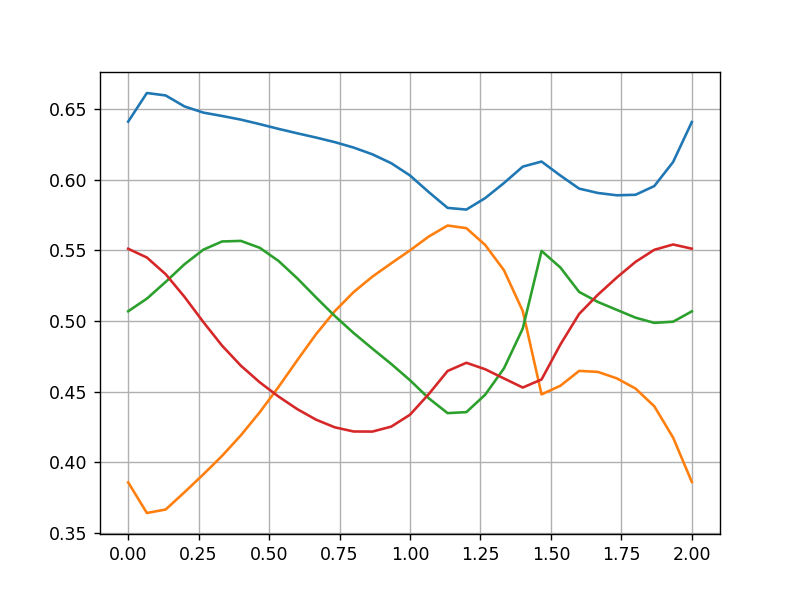

In [57]:
plt.plot(phi_0/np.pi, n_lambd)


plt.grid()

<IPython.core.display.Javascript object>


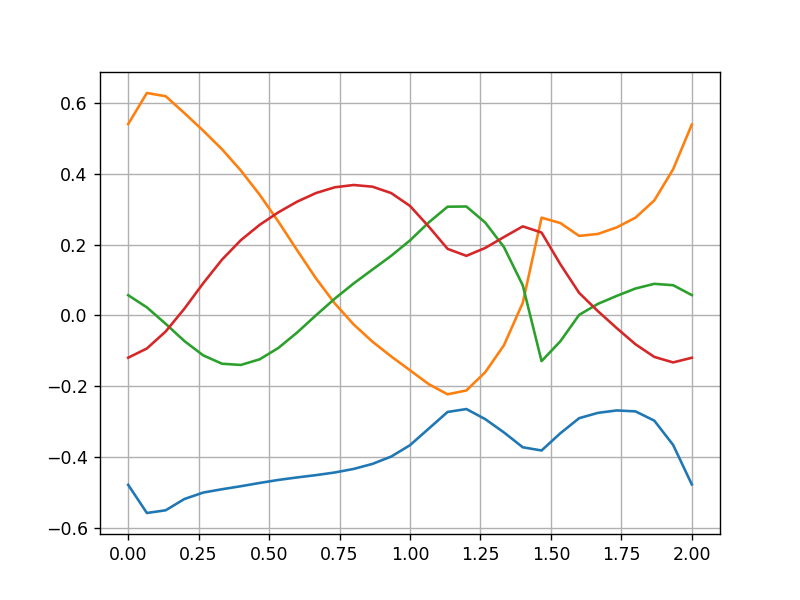

In [58]:
plt.plot(phi_0/np.pi, MF_param_new)

plt.grid()

#### Checking convergence

In [59]:
abs_diff = np.abs(MF_param_new-MF_param)

<IPython.core.display.Javascript object>


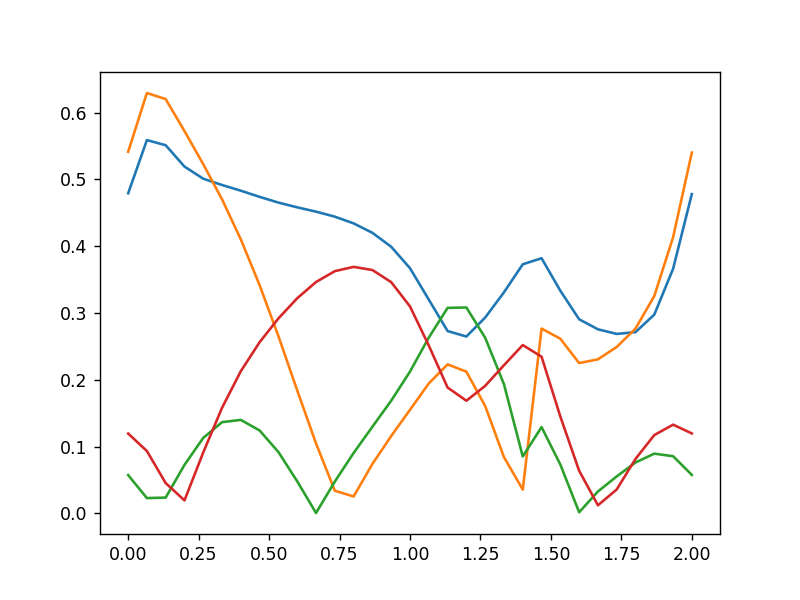

In [60]:
plt.plot(phi_0/np.pi, abs_diff)

In [61]:
MF_param = MF_param_new

## MFA loop

In [411]:
# MF_param = np.zeros((len(phi_0), 2*l))
# accur_par = 6*1e-3
# abs_diff = np.full((len(phi_0), 2*l), np.inf)

# MFA_count = 0
# max_iter = 7

### Less effective MFA algorithm, no indices reduction

In [479]:
# while MFA_count < max_iter and np.any(abs_diff > accur_par):
    
#     # computing ABS energies
#     for i in range(len(phi_0)):
#         roots[i, 0] = fsolve(G_inv, 0.7, args=(i, MF_param))  
#         roots[i, 1] = fsolve(G_inv, 0.8, args=(i, MF_param))  #0.65   
#         roots[i, 2] = fsolve(G_inv, 0.9, args=(i, MF_param))  #0.86
#         roots[i, 3] = fsolve(G_inv, 0.9999, args=(i, MF_param))

#         roots[i, 4] = fsolve(G_inv, -0.7, args=(i, MF_param))  
#         roots[i, 5] = fsolve(G_inv, -0.8, args=(i, MF_param))     
#         roots[i, 6] = fsolve(G_inv, -0.9, args=(i, MF_param))  
#         roots[i, 7] = fsolve(G_inv, -0.9999, args=(i, MF_param)) 

    
#     # ABS eigenvectors
#     eigv_0 = np.zeros((len(phi_0), 4*l))
#     eigvec_0 = np.zeros((len(phi_0), 4*l, 4*l), dtype='complex')

#     eigv_1 = np.zeros((len(phi_0), 4*l))
#     eigvec_1 = np.zeros((len(phi_0), 4*l, 4*l), dtype='complex')

#     eigv_2 = np.zeros((len(phi_0), 4*l))
#     eigvec_2 = np.zeros((len(phi_0), 4*l, 4*l), dtype='complex')

#     eigv_3 = np.zeros((len(phi_0), 4*l))
#     eigvec_3 = np.zeros((len(phi_0), 4*l, 4*l), dtype='complex')

#     eigv_4 = np.zeros((len(phi_0), 4*l))
#     eigvec_4 = np.zeros((len(phi_0), 4*l, 4*l), dtype='complex')

#     eigv_5 = np.zeros((len(phi_0), 4*l))
#     eigvec_5 = np.zeros((len(phi_0), 4*l, 4*l), dtype='complex')

#     eigv_6 = np.zeros((len(phi_0), 4*l))
#     eigvec_6 = np.zeros((len(phi_0), 4*l, 4*l), dtype='complex')

#     eigv_7 = np.zeros((len(phi_0), 4*l))
#     eigvec_7 = np.zeros((len(phi_0), 4*l, 4*l), dtype='complex')
    
#     for i in range(len(phi_0)):
#         eigv_0[i], eigvec_0[i] = diagonal(roots[:, 0], i, MF_param)
#         eigv_1[i], eigvec_1[i] = diagonal(roots[:, 1], i, MF_param)
#         eigv_2[i], eigvec_2[i] = diagonal(roots[:, 2], i, MF_param)
#         eigv_3[i], eigvec_3[i] = diagonal(roots[:, 3], i, MF_param)

#         eigv_4[i], eigvec_4[i] = diagonal(roots[:, 4], i, MF_param)
#         eigv_5[i], eigvec_5[i] = diagonal(roots[:, 5], i, MF_param)
#         eigv_6[i], eigvec_6[i] = diagonal(roots[:, 6], i, MF_param)
#         eigv_7[i], eigvec_7[i] = diagonal(roots[:, 7], i, MF_param)
    
#     # Eigenvectors corresponding to the Andreev energies
#     eta_0 = eigvec_0[:, :, 4]
#     eta_1 = eigvec_1[:, :, 5]
#     eta_2 = eigvec_2[:, :, 6]
#     eta_3 = eigvec_3[:, :, 7]

#     eta_4 = eigvec_4[:, :, 3]
#     eta_5 = eigvec_5[:, :, 2]
#     eta_6 = eigvec_6[:, :, 1]
#     eta_7 = eigvec_7[:, :, 0]

#     eta_arr = np.stack([eta_0, eta_1, eta_2, eta_3, eta_4, eta_5, eta_6, eta_7], axis=0)
    
#     # Bogoliubov transformation for the dot -> Andreev fermions 
#     M = np.zeros((len(phi_0), 8, 8), dtype='complex')

#     # Fill M[:, 0:4, :] with the conjugates of eta_0 to eta_3
#     M[:, 0, :] = np.conj(eta_0)
#     M[:, 1, :] = np.conj(eta_1)
#     M[:, 2, :] = np.conj(eta_2)
#     M[:, 3, :] = np.conj(eta_3)

#     # For rows 4 to 7, split and assign parts
#     for i, eta in enumerate([eta_0, eta_1, eta_2, eta_3]):
#         M[:, 4 + i, 0:4] = eta[:, 4:]
#         M[:, 4 + i, 4:] = eta[:, 0:4]

#     M_inv = LA.inv(M)
#     a = np.sum(np.abs(M_inv[:, 0:4, 4:])**2, axis=1)

#     # weight of each number of part operator n_i, i in [1, 4]
#     a_i = np.abs(M_inv[:, 0:4, 0:4])**2 - np.abs(M_inv[:, 4:, 0:4])**2

#     # Current elements
#     I_nl = np.zeros((len(phi_0), 4*l, 4*l), dtype='complex')
#     G_nl = np.zeros((len(phi_0), 4*l, 4*l))

#     for i in range(len(phi_0)):
#         for n in range(4*l):
#             for lamd in range(4*l):
#                 I_nl[i, n ,lamd] = curr_nl(roots[i, n], roots[i, lamd], eta_arr[n, i], eta_arr[lamd, i], i)
                
#     # ABS -> ABS transition rates
#     for i in range(len(phi_0)):
#         for n in range(4*l):
#             for lamd in range(4*l):

#                 energy_diff = roots[i, n] - roots[i, lamd]
#                 J_spect = spectral_density(energy_diff, lambda_coupl, alpha_0, damping_param, Omega, omega_c)
#                 bose = bose_distrib(energy_diff, T_bos)

#                 G_nl[i, lamd, n] = 2*np.pi * np.abs(I_nl[i, n, lamd])**2 * J_spect * bose 

#                 if math.isnan(G_nl[i, lamd, n]):
#                     G_nl[i, lamd, n] = 0
    
    
#     G_AL_pp = G_nl[:, 0:4, 0:4]
#     G_AL_pm = G_nl[:, 0:4, 4:8]
#     G_AL_mp = G_nl[:, 4:8, 0:4]
    
    
#     # ABS -> continuum transition rates 
#     Gamma_out_pc = np.zeros((len(phi_0), 4))
#     Gamma_out_mc = np.zeros_like(Gamma_out_pc) 
#     Gamma_in_pc = np.zeros_like(Gamma_out_pc)
#     Gamma_in_mc = np.zeros_like(Gamma_out_pc)

#     # Use ProcessPoolExecutor for parallel execution
#     with ProcessPoolExecutor() as executor:

#         # Create a list of futures by submitting tasks for parallel execution
#         futures = [executor.submit(compute_integrals, i, lamd, Delta, T_bos, T_ferm,\
#                         lambda_coupl, alpha_0, damping_param, Omega, omega_c)
#                    for i in range(len(phi_0)) for lamd in range(4)]

#         # Collect results as they are completed
#         for future in futures:
#             i, lamd, out_pc, out_mc, in_pc, in_mc = future.result()

#             # Store results in the appropriate arrays
#             Gamma_out_pc[i, lamd] = out_pc
#             Gamma_out_mc[i, lamd] = out_mc
#             Gamma_in_pc[i, lamd] = in_pc
#             Gamma_in_mc[i, lamd] = in_mc

#     Gamma_in = (Gamma_in_pc + Gamma_in_mc) * 2*np.pi
#     Gamma_out = (Gamma_out_pc + Gamma_out_mc) * 2*np.pi
    
    
#     # Steady state 
   
#     Steady_M = np.zeros((len(phi_0), N_state, N_state), dtype='float64') 

#     for j in range(len(phi_0)):

#         # loop over the raws - as many as there are states - 16
#         for i in range(N_state):

#             # loop over 4 levels
#             for mu in range(4):

#                 n_mu = nf_h[i, mu]

#                 # G_in
#                 Steady_M[j, i, i + (-1)**n_mu * 2**mu] += n_mu * (Gamma_in[j, mu] )

#                 # G_out
#                 Steady_M[j, i, i + (-1)**n_mu * 2**mu] += (1-n_mu) * (Gamma_out[j, mu] )

#                 # G_in, G_out
#                 Steady_M[j, i, i] -= n_mu * (Gamma_out[j, mu]) + \
#                                     (1-n_mu) * (Gamma_in[j, mu] )

#         #             loop over lambda' != lamda
#                 for nu in chain(range(mu), range(mu+1, 4)):

#                     n_nu = nf_h[i, nu]

#                     Steady_M[j, i, i + (-1)**n_mu * 2**mu + (-1)**n_nu * 2**nu] += \
#                                     n_mu * (1-n_nu) * G_AL_pp[j, nu, mu] + \
#                                     n_mu * n_nu * G_AL_mp[j, nu, mu] + \
#                                     (1-n_mu) * (1-n_nu) * G_AL_pm[j, nu, mu]

#                     Steady_M[j, i, i] -= (1-n_mu) * n_nu * G_AL_pp[j, nu, mu] + \
#                                              (1-n_mu) * (1-n_nu) * G_AL_mp[j, nu, mu] +\
#                                              n_mu * n_nu * G_AL_pm[j, nu, mu]

                    
#     ns = np.zeros((len(phi_0), 16), dtype='float64')

#     for i in range(len(phi_0)):
#         ns[i] = null_space(Steady_M[i], rcond=10e-16)[:,0]

#     steady_occup = ns
#     steady_occup /= np.sum(steady_occup, axis=1, keepdims=True)

#     # Computing accuracy and updating MF_param 
#     weight = np.einsum('km,ijm->ijk', nf_h, a_i)
#     n_lambd = np.sum(weight * steady_occup[:, None, :], axis=2) + a

#     X_matr = n_lambd[:, :, None] - n_lambd[:, None, :]
#     MF_param_new = np.sum(X_matr, axis=1)
#     abs_diff = np.abs(MF_param_new-MF_param)    

#     # Print progress

#     print("differences:", abs_diff)  
#     MF_param = MF_param_new    
#     MFA_count += 1
       

### Effective MFA algorithm, with converged phi_0 indices reduction

In [141]:
# initializing the MFA procedure

MF_param = np.zeros((len(phi_0), 2*l), dtype='complex')
accur_par = 0.2
abs_diff = np.full((len(phi_0), 2*l), np.inf)

MFA_count = 0
max_iter = 10
active_mask = np.full(len(phi_0), True)  # True = not converged

In [170]:
MFA_count = 0
accur_par = 6*10**(-3)
active_mask = np.full(len(phi_0), True)  # True = not converged

In [171]:
while MFA_count < max_iter and np.any(active_mask):

    # Select indices where not converged
    active_indices = np.where(active_mask)[0]
    
    # You may want to skip empty active_indices check for safety
    if len(active_indices) == 0:
        break
    
    # --- 1. Compute all roots, will use only active further ---
    roots = np.zeros((len(phi_0), 4*l))   
    
    for i in range(len(phi_0)):
        roots[i, 0] = fsolve(G_inv, 0.55, args=(i, MF_param))
        roots[i, 1] = fsolve(G_inv, 0.7, args=(i, MF_param))
        roots[i, 2] = fsolve(G_inv, 0.8, args=(i, MF_param))
        roots[i, 3] = fsolve(G_inv, 0.99, args=(i, MF_param))
        roots[i, 4] = fsolve(G_inv, -0.55, args=(i, MF_param))
        roots[i, 5] = fsolve(G_inv, -0.7, args=(i, MF_param))
        roots[i, 6] = fsolve(G_inv, -0.8, args=(i, MF_param))
        roots[i, 7] = fsolve(G_inv, -0.99, args=(i, MF_param))

    # --- 2. Compute eigenvalues/eigenvectors for active indices ---
    
    eigv_ = np.zeros((len(active_indices), 4*l, 4*l))
    eigvec_ = np.zeros((len(active_indices), 4*l, 4*l, 4*l), dtype='complex')

    for k in range(4*l):
        for idx, i in enumerate(active_indices):
            eigv_[idx, :, k], eigvec_[idx, :, :, k] = diagonal(roots[:, k], i, MF_param)

    
    # Eigenvectors corresponding to the Andreev energies
    eta_0 = eigvec_[:, :, 4, 0]
    eta_1 = eigvec_[:, :, 5, 1]
    eta_2 = eigvec_[:, :, 6, 2]
    eta_3 = eigvec_[:, :, 7, 3]

    eta_4 = eigvec_[:, :, 3, 4]
    eta_5 = eigvec_[:, :, 2, 5]
    eta_6 = eigvec_[:, :, 1, 6]
    eta_7 = eigvec_[:, :, 0, 7]

    eta_arr = np.stack([eta_0, eta_1, eta_2, eta_3, eta_4, eta_5, eta_6, eta_7], axis=0)

    # --- 3. Compute eta_arr, M, M_inv, a_i, etc. for active_indices ---
    # Make sure these computations only use active_indices slices
    
    # Bogoliubov transformation for the dot -> Andreev fermions 
    M = np.zeros((len(active_indices), 8, 8), dtype='complex')

    # Fill M[:, 0:4, :] with the conjugates of eta_0 to eta_3
    M[:, 0, :] = np.conj(eta_0)
    M[:, 1, :] = np.conj(eta_1)
    M[:, 2, :] = np.conj(eta_2)
    M[:, 3, :] = np.conj(eta_3)

    # For rows 4 to 7, split and assign parts
    for i, eta in enumerate([eta_0, eta_1, eta_2, eta_3]):
        M[:, 4 + i, 0:4] = eta[:, 4:]
        M[:, 4 + i, 4:] = eta[:, 0:4]

    M_inv = LA.inv(M)
    a = np.sum(np.abs(M_inv[:, 0:4, 4:])**2, axis=1)

    # weight of each number of part operator n_i, i in [1, 4]
    a_i = np.abs(M_inv[:, 0:4, 0:4])**2 - np.abs(M_inv[:, 4:, 0:4])**2

    # --- 4. Compute current elements I_nl and rates G_nl for active_indices ---
    
    # Current elements
    I_nl = np.zeros((len(active_indices), 4*l, 4*l), dtype='complex')
    G_nl = np.zeros((len(active_indices), 4*l, 4*l))

    for idx, i in enumerate(active_indices):
        for n in range(4*l):
            for lamd in range(4*l):
                I_nl[idx, n, lamd] = curr_nl(
                    roots[i, n],
                    roots[i, lamd],
                    eta_arr[n, idx],
                    eta_arr[lamd, idx],
                    i)
                
    # ABS -> ABS transition rates
    for idx, i in enumerate(active_indices):
        for n in range(4*l):
            for lamd in range(4*l):

                energy_diff = roots[i, n] - roots[i, lamd]
                J_spect = spectral_density(energy_diff, lambda_coupl, alpha_0, damping_param, Omega, omega_c)
                bose = bose_distrib(energy_diff, T_bos)

                G_nl[idx, lamd, n] = 2 * np.pi * np.abs(I_nl[idx, n, lamd])**2 * J_spect * bose

                if math.isnan(G_nl[idx, lamd, n]):
                    G_nl[idx, lamd, n] = 0
    
    
    G_AL_pp = G_nl[:, 0:4, 0:4]
    G_AL_pm = G_nl[:, 0:4, 4:8]
    G_AL_mp = G_nl[:, 4:8, 0:4]

    
    # --- 5. Compute Gamma_in_pc, Gamma_out_pc, Gamma_in_mc, Gamma_out_mc ---
    
    # ABS -> continuum transition rates 
    Gamma_out_pc = np.zeros((len(active_indices), 4))
    Gamma_out_mc = np.zeros_like(Gamma_out_pc) 
    Gamma_in_pc = np.zeros_like(Gamma_out_pc)
    Gamma_in_mc = np.zeros_like(Gamma_out_pc)

    # Use ProcessPoolExecutor for parallel execution
    with ProcessPoolExecutor() as executor:

        # Create a list of futures by submitting tasks for parallel execution
        futures = [executor.submit(compute_integrals, idx, i, lamd, Delta, T_bos, T_ferm,\
                    lambda_coupl, alpha_0, damping_param, Omega, omega_c)
               for idx, i in enumerate(active_indices) for lamd in range(4)]
            
        # Collect results as they are completed
        for future in futures:
            idx, lamd, out_pc, out_mc, in_pc, in_mc = future.result()

            Gamma_out_pc[idx, lamd] = out_pc
            Gamma_out_mc[idx, lamd] = out_mc
            Gamma_in_pc[idx, lamd]  = in_pc
            Gamma_in_mc[idx, lamd]  = in_mc

            
    Gamma_in = (Gamma_in_pc + Gamma_in_mc) * 2*np.pi
    Gamma_out = (Gamma_out_pc + Gamma_out_mc) * 2*np.pi
    
    # --- 6. Build Steady_M matrices for active_indices ---
    
    # Steady state 
    Steady_M = np.zeros((len(active_indices), N_state, N_state), dtype='float64') 

    for idx, j in enumerate(active_indices):
        # loop over the raws - as many as there are states - 16
        for i in range(N_state):

            # loop over 4 levels
            for mu in range(4):

                n_mu = nf_h[i, mu]

                # G_in
                Steady_M[idx, i, i + (-1)**n_mu * 2**mu] += n_mu * (Gamma_in[idx, mu] )

                # G_out
                Steady_M[idx, i, i + (-1)**n_mu * 2**mu] += (1-n_mu) * (Gamma_out[idx, mu] )

                # G_in, G_out
                Steady_M[idx, i, i] -= n_mu * (Gamma_out[idx, mu]) + \
                                    (1-n_mu) * (Gamma_in[idx, mu] )

        #             loop over lambda' != lamda
                for nu in chain(range(mu), range(mu+1, 4)):

                    n_nu = nf_h[i, nu]

                    Steady_M[idx, i, i + (-1)**n_mu * 2**mu + (-1)**n_nu * 2**nu] += \
                                    n_mu * (1-n_nu) * G_AL_pp[idx, nu, mu] + \
                                    n_mu * n_nu * G_AL_mp[idx, nu, mu] + \
                                    (1-n_mu) * (1-n_nu) * G_AL_pm[idx, nu, mu]

                    Steady_M[idx, i, i] -= (1-n_mu) * n_nu * G_AL_pp[idx, nu, mu] + \
                                             (1-n_mu) * (1-n_nu) * G_AL_mp[idx, nu, mu] +\
                                             n_mu * n_nu * G_AL_pm[idx, nu, mu]
    
    # --- 7. Compute steady state occupation ns for active_indices ---
    
    ns = np.zeros((len(active_indices), 16), dtype='float64')

    for idx, i in enumerate(active_indices):
        ns[idx] = null_space(Steady_M[idx], rcond=1e-16)[:, 0]
        
    steady_occup = ns
    steady_occup /= np.sum(steady_occup, axis=1, keepdims=True)
    
    # --- 8. Compute new MF_param for active_indices ---
   
    # Computing accuracy and updating MF_param 
    weight = np.einsum('km,ijm->ijk', nf_h, a_i)
    n_lambd = np.sum(weight * steady_occup[:, None, :], axis=2) + a
    
    X_matr = n_lambd[:, :, None] - n_lambd[:, None, :]
    MF_param_new_active = np.sum(X_matr, axis=1)

    # --- 9. Update abs_diff for active_indices ---
    abs_diff[active_indices] = np.abs(MF_param_new_active - MF_param[active_indices])

    # --- 10. Update MF_param for active_indices ---
    MF_param[active_indices] = MF_param_new_active

    # --- 11. Update active_mask: mark converged points as False ---
    converged = np.all(abs_diff[active_indices] <= accur_par, axis=1)
    for idx, conv in zip(active_indices, converged):
        if conv:
            active_mask[idx] = False

    MFA_count += 1
    
    print(f"Iteration {MFA_count}, points left to converge: {np.sum(active_mask)}")
    print("Max difference among active points:", np.max(abs_diff[active_indices]))

# After loop: MF_param contains converged (or last iterated) parameters

/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: divide by zero encountered in double_scalars
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/2282531391.py:94: RuntimeWarning: invalid value encountered in double_scalars
  G_nl[idx, lamd, n] = 2 * np.pi * np.abs(I_nl[idx, n, lamd])**2 * J_spect * bose
/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190076.py:4: RuntimeW

Iteration 1, points left to converge: 31
Max difference among active points: 0.1812873073812355


/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190

Iteration 2, points left to converge: 30
Max difference among active points: 0.251246793551434


/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190

...

Iteration 8, points left to converge: 13
Max difference among active points: 0.22262214445898276


/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190

Iteration 9, points left to converge: 13
Max difference among active points: 0.22637720458864075


/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190

Iteration 10, points left to converge: 12
Max difference among active points: 0.2324032672381856


In [168]:
print(MF_param)

[[ 0.20359479+0.j -0.04877086+0.j -0.11516326+0.j -0.03966067+0.j]
 [ 0.1099349 +0.j  0.04315415+0.j -0.10286854+0.j -0.05022051+0.j]
 [ 0.05360081+0.j  0.063403  +0.j -0.06274442+0.j -0.05425939+0.j]
 [-0.20437675+0.j  0.28021926+0.j -0.20263282+0.j  0.12679032+0.j]
 [-0.14754841+0.j  0.17875132+0.j -0.06519632+0.j  0.03399341+0.j]
 [-0.40150083+0.j  0.35685004+0.j -0.2389641 +0.j  0.28361489+0.j]
 [-0.44193906+0.j  0.33759222+0.j -0.22206737+0.j  0.32641421+0.j]
 [-0.4903801 +0.j  0.32971737+0.j -0.23418476+0.j  0.39484749+0.j]
 [-0.56968187+0.j  0.285993  +0.j -0.21186993+0.j  0.4955588 +0.j]
 [-0.55634244+0.j  0.02465359+0.j  0.05305771+0.j  0.47863114+0.j]
 [-0.52870633+0.j -0.24507411+0.j  0.33726577+0.j  0.43651467+0.j]
 [-0.08411266+0.j -0.94098457+0.j  1.13168929+0.j -0.10659207+0.j]
 [-0.14001542+0.j -0.96714349+0.j  1.15583148+0.j -0.04867257+0.j]
 [-0.14890262+0.j -0.9947772 +0.j  1.18210332+0.j -0.03842351+0.j]
 [-0.14861688+0.j -1.03482759+0.j  1.21787061+0.j -0.03442614+

<IPython.core.display.Javascript object>


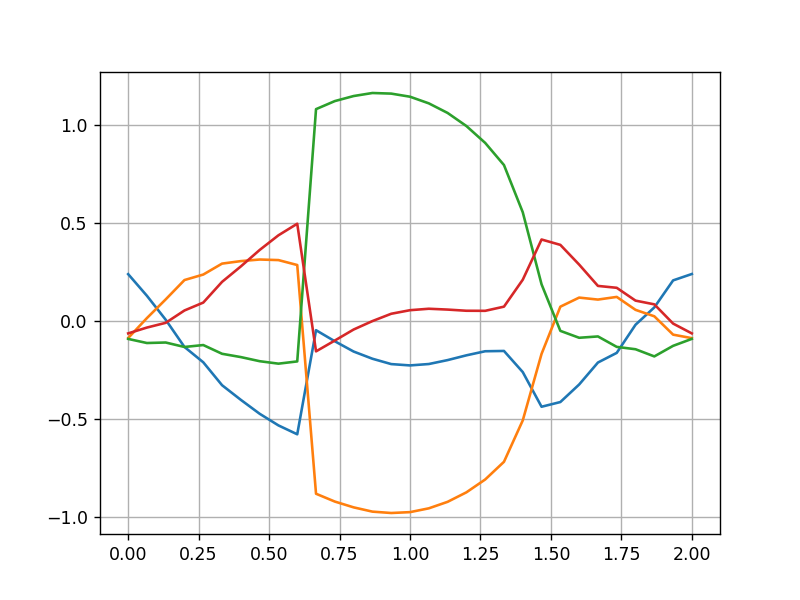

In [172]:
plt.plot(phi_0/np.pi, MF_param)
# plt.plot(phi_0/np.pi, MF_param_final)
plt.grid()

<IPython.core.display.Javascript object>


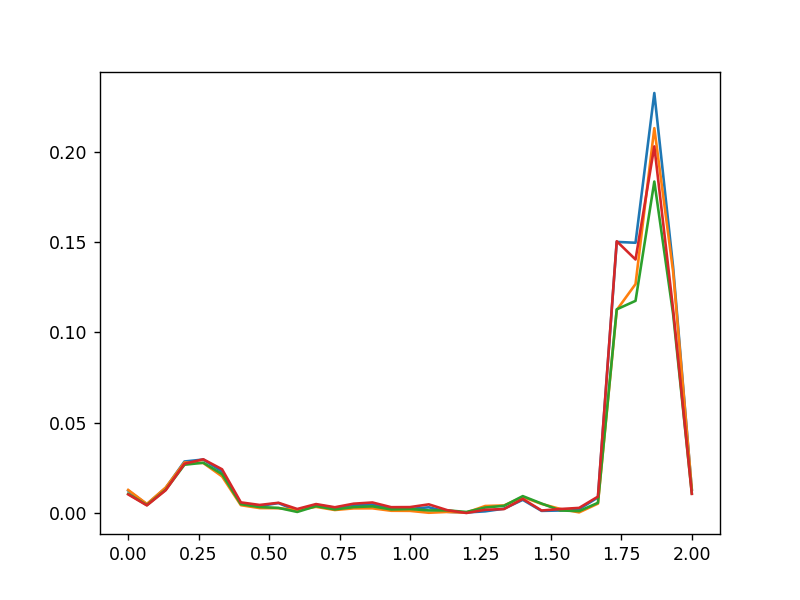

In [173]:
plt.plot(phi_0/np.pi, abs_diff)

In [174]:
# saving the converged MF parameters

# np.save("MF_param_bx=0.21,bz=0.2, SO=0.1.npy", MF_param_final)
MF_param_final = MF_param
# MF_param_final = np.load("MF_param_bx=0.21,bz=0.2, SO=0.1.npy") # loading MF_param

### Compute the current

In [175]:
roots = np.zeros((len(phi_0), 4*l))

for i in range(len(phi_0)):
    
    roots[i, 0] = fsolve(G_inv, 0.55, args=(i, MF_param_final))  
    roots[i, 1] = fsolve(G_inv, 0.7, args=(i, MF_param_final))  #0.65   
    roots[i, 2] = fsolve(G_inv, 0.8, args=(i, MF_param_final))  #0.86
    roots[i, 3] = fsolve(G_inv, 0.99, args=(i, MF_param_final))

    roots[i, 4] = fsolve(G_inv, -0.55, args=(i, MF_param_final))  
    roots[i, 5] = fsolve(G_inv, -0.7, args=(i, MF_param_final))     
    roots[i, 6] = fsolve(G_inv, -0.8, args=(i, MF_param_final))  
    roots[i, 7] = fsolve(G_inv, -0.99, args=(i, MF_param_final)) 

<IPython.core.display.Javascript object>


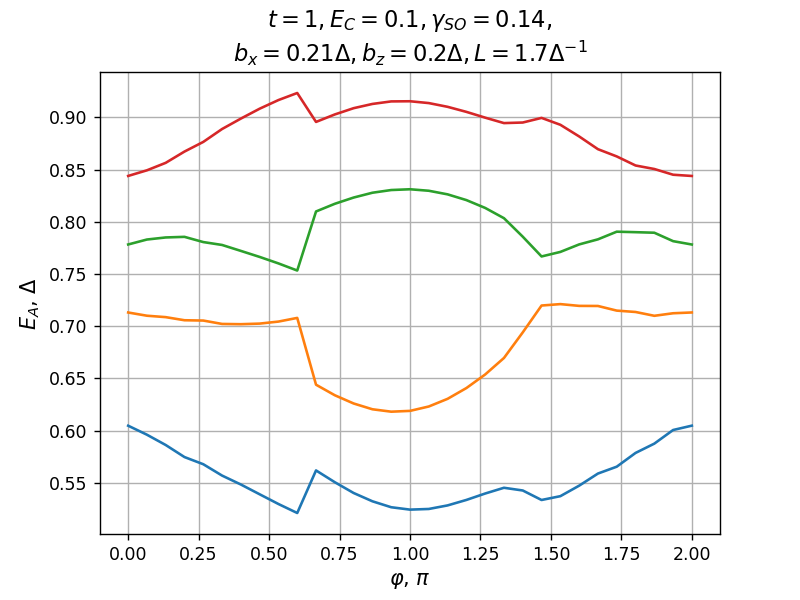

Text(0, 0.5, '$E_A$, $\\Delta$')

In [176]:
plt.plot(phi_0/np.pi, roots[:,0], linewidth=1.5)
plt.plot(phi_0/np.pi, roots[:,1], linewidth=1.5)
plt.plot(phi_0/np.pi, roots[:,2], linewidth=1.5)
plt.plot(phi_0/np.pi, roots[:,3], linewidth=1.5)


plt.title(r"$t={}, E_C={}, \gamma_{{SO}} = {},$"\
          .format(t_L, Ec, gamma_SO)+'\n'+
          r"$b_x={}\Delta, b_z = {}\Delta, L={}\Delta^{{-1}}$"\
          .format(np.round(b_x, 2), np.round(b_z, 2), L), fontsize=13)



plt.grid()
plt.xlabel(r'$\varphi$, $\pi$', fontsize=12)
plt.ylabel(r'$E_A$, $\Delta$', fontsize=12)

In [177]:
eigv_ = np.zeros((len(phi_0), 4*l, 4*l))
eigvec_ = np.zeros((len(phi_0), 4*l, 4*l, 4*l), dtype='complex')

for k in range(4*l):
    for i in range(len(phi_0)):
        eigv_[i, :, k], eigvec_[i, :, :, k] = diagonal(roots[:, k], i, MF_param_final)


# Eigenvectors corresponding to the Andreev energies
eta_0 = eigvec_[:, :, 4, 0]
eta_1 = eigvec_[:, :, 5, 1]
eta_2 = eigvec_[:, :, 6, 2]
eta_3 = eigvec_[:, :, 7, 3]

eta_4 = eigvec_[:, :, 3, 4]
eta_5 = eigvec_[:, :, 2, 5]
eta_6 = eigvec_[:, :, 1, 6]
eta_7 = eigvec_[:, :, 0, 7]

eta_arr = np.stack([eta_0, eta_1, eta_2, eta_3, eta_4, eta_5, eta_6, eta_7], axis=0)

In [178]:
# Current elements
    
I_nl = np.zeros((len(phi_0), 4*l, 4*l), dtype='complex')
G_nl = np.zeros((len(phi_0), 4*l, 4*l))

for i in range(len(phi_0)):
    for n in range(4*l):
        for lamd in range(4*l):
            I_nl[i, n ,lamd] = curr_nl(roots[i, n], roots[i, lamd], eta_arr[n, i], eta_arr[lamd, i], i)

# ABS -> ABS transition rates

for i in range(len(phi_0)):
    for n in range(4*l):
        for lamd in range(4*l):

            energy_diff = roots[i, n] - roots[i, lamd]
            J_spect = spectral_density(energy_diff, lambda_coupl, alpha_0, damping_param, Omega, omega_c)
            bose = bose_distrib(energy_diff, T_bos)

            G_nl[i, lamd, n] = 2*np.pi * np.abs(I_nl[i, n, lamd])**2 * J_spect * bose 

            if math.isnan(G_nl[i, lamd, n]):
                G_nl[i, lamd, n] = 0


G_AL_pp = G_nl[:, 0:4, 0:4]
G_AL_pm = G_nl[:, 0:4, 4:8]
G_AL_mp = G_nl[:, 4:8, 0:4]

/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: divide by zero encountered in double_scalars
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/1350055869.py:21: RuntimeWarning: invalid value encountered in double_scalars
  G_nl[i, lamd, n] = 2*np.pi * np.abs(I_nl[i, n, lamd])**2 * J_spect * bose


/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190076.py:4: RuntimeWarning: overflow encountered in exp
  n_B = 1/(np.exp(x/T)-1)
/tmp/ipykernel_68857/4160190

<IPython.core.display.Javascript object>


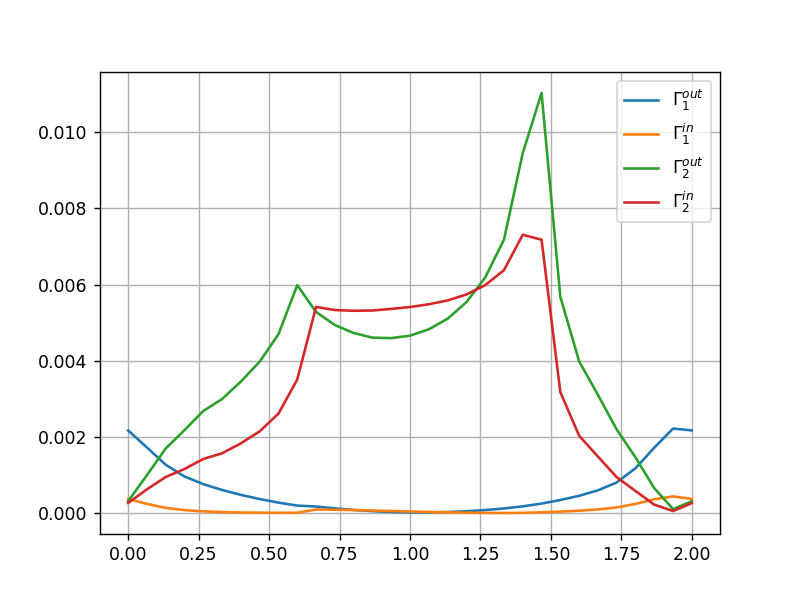

In [181]:
# ABS -> continuum transition rates
    
Gamma_out_pc = np.zeros((len(phi_0), 4))
Gamma_out_mc = np.zeros_like(Gamma_out_pc) 
Gamma_in_pc = np.zeros_like(Gamma_out_pc)
Gamma_in_mc = np.zeros_like(Gamma_out_pc)

# Use ProcessPoolExecutor for parallel execution
with ProcessPoolExecutor() as executor:
    
    # Create a list of futures by submitting tasks for parallel execution
    futures = [executor.submit(compute_integrals, idx, i, lamd, Delta, T_bos, T_ferm,\
                    lambda_coupl, alpha_0, damping_param, Omega, omega_c)
               for idx, i in enumerate(range(len(phi_0))) for lamd in range(4)]
    
    # Collect results as they are completed
    for future in futures:
        i, lamd, out_pc, out_mc, in_pc, in_mc = future.result()
        
        # Store results in the appropriate arrays
        Gamma_out_pc[i, lamd] = out_pc
        Gamma_out_mc[i, lamd] = out_mc
        Gamma_in_pc[i, lamd] = in_pc
        Gamma_in_mc[i, lamd] = in_mc


Gamma_in = (Gamma_in_pc + Gamma_in_mc) * 2*np.pi
Gamma_out = (Gamma_out_pc + Gamma_out_mc) * 2*np.pi

plt.plot(phi_0/np.pi, Gamma_out[:, 0], label=r'$\Gamma^{out}_1$')
plt.plot(phi_0/np.pi, Gamma_in[:, 0], label=r'$\Gamma^{in}_1$')

plt.plot(phi_0/np.pi, Gamma_out[:, 1], label=r'$\Gamma^{out}_{2}$')
plt.plot(phi_0/np.pi, Gamma_in[:, 1], label=r'$\Gamma^{in}_{2}$')

plt.legend()
plt.grid()


In [183]:
# Steady state
    
Steady_M = np.zeros((len(phi_0), N_state, N_state), dtype='float64') 

for j in range(len(phi_0)):

    # loop over the raws - as many as there are states - 16
    for i in range(N_state):

        # loop over 4 levels
        for mu in range(4):

            n_mu = nf_h[i, mu]

            # G_in
            Steady_M[j, i, i + (-1)**n_mu * 2**mu] += n_mu * (Gamma_in[j, mu] )

            # G_out
            Steady_M[j, i, i + (-1)**n_mu * 2**mu] += (1-n_mu) * (Gamma_out[j, mu] )

            # G_in, G_out
            Steady_M[j, i, i] -= n_mu * (Gamma_out[j, mu]) + \
                                (1-n_mu) * (Gamma_in[j, mu] )

    #             loop over lambda' != lamda
            for nu in chain(range(mu), range(mu+1, 4)):

                n_nu = nf_h[i, nu]

                Steady_M[j, i, i + (-1)**n_mu * 2**mu + (-1)**n_nu * 2**nu] += \
                                n_mu * (1-n_nu) * G_AL_pp[j, nu, mu] + \
                                n_mu * n_nu * G_AL_mp[j, nu, mu] + \
                                (1-n_mu) * (1-n_nu) * G_AL_pm[j, nu, mu]

                Steady_M[j, i, i] -= (1-n_mu) * n_nu * G_AL_pp[j, nu, mu] + \
                                         (1-n_mu) * (1-n_nu) * G_AL_mp[j, nu, mu] +\
                                         n_mu * n_nu * G_AL_pm[j, nu, mu]



<IPython.core.display.Javascript object>


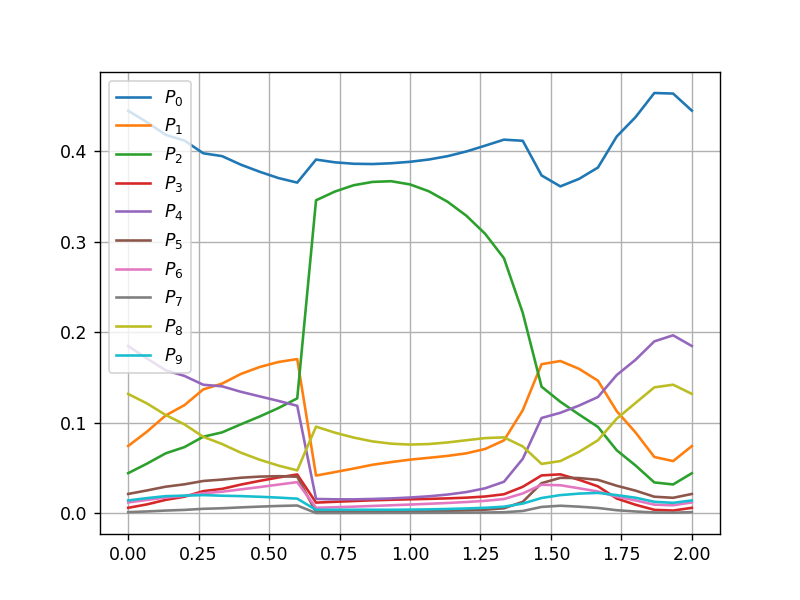

In [184]:
ns = np.zeros((len(phi_0), 16), dtype='float64')

for i in range(len(phi_0)):
    ns[i] = null_space(Steady_M[i], rcond=10e-16)[:,0]
#         print(i, LA.matrix_rank(Steady_M[i]))

steady_occup_final = ns
steady_occup_final /= np.sum(steady_occup_final, axis=1, keepdims=True)
    
plt.plot(phi_0/np.pi, steady_occup_final[:, 0], label=r'$P_0$')
plt.plot(phi_0/np.pi, steady_occup_final[:, 1], label=r'$P_1$')
plt.plot(phi_0/np.pi, steady_occup_final[:, 2], label=r'$P_2$')
plt.plot(phi_0/np.pi, steady_occup_final[:, 3], label=r'$P_3$')
plt.plot(phi_0/np.pi, steady_occup_final[:, 4], label=r'$P_4$')
plt.plot(phi_0/np.pi, steady_occup_final[:, 5], label=r'$P_5$')
plt.plot(phi_0/np.pi, steady_occup_final[:, 6], label=r'$P_6$')
plt.plot(phi_0/np.pi, steady_occup_final[:, 7], label=r'$P_7$')
plt.plot(phi_0/np.pi, steady_occup_final[:, 8], label=r'$P_8$')
plt.plot(phi_0/np.pi, steady_occup_final[:, 9], label=r'$P_9$')
# plt.plot(phi_0/np.pi, steady_occup_final[:, 10], label=r'$P_{10}$')
# plt.plot(phi_0/np.pi, steady_occup_final[:, 11], label=r'$P_{11}$')

plt.grid()
plt.legend()

In [83]:
# save or load the steady state

np.save("steady_occup_final_bx,bz=0.1, SO=0.2.npy", steady_occup_final)
# steady_occup_final = np.load("steady_occup_final_bx,bz=0.1, SO=0.2.npy") # loading MF_param

In [185]:
w_lamb = np.sum(nf_h[None, :, :] * steady_occup_final[:, :, None], axis=1)

In [159]:
def current_cont(E, MF_param, dx, T_ferm):
    
    eigv_c = np.zeros((len(phi_0), 8))
    eigvect_c = np.zeros((len(phi_0), 8, 8), dtype='complex')

    for i in range(len(phi_0)):
        eigv_c[i], eigvect_c[i] = spectr(E, i, MF_param)
    
    grad_c = np.gradient(eigv_c, dx, axis=0, edge_order=2)
    sum_grad = np.sum(grad_c[:, 0:4], axis=1)
    
    return sum_grad * (2*fermi_distrib(E, T_ferm) - 1)

In [186]:
dx = 2*np.pi/len(phi_0)
grad = np.gradient(roots, dx, axis=0, edge_order=2)

# Andreev current
I_A = np.sum(grad[:, 0:4] * (2*w_lamb - 1), axis=1) 

# continuum current
I_cont = quad_vec(current_cont, Delta, np.infty, args=(MF_param_final, dx, T_ferm))[0]

I = I_A + I_cont

/tmp/ipykernel_68857/3358550317.py:2: RuntimeWarning: overflow encountered in exp
  return 1/(np.exp(x/T)+1)


<IPython.core.display.Javascript object>


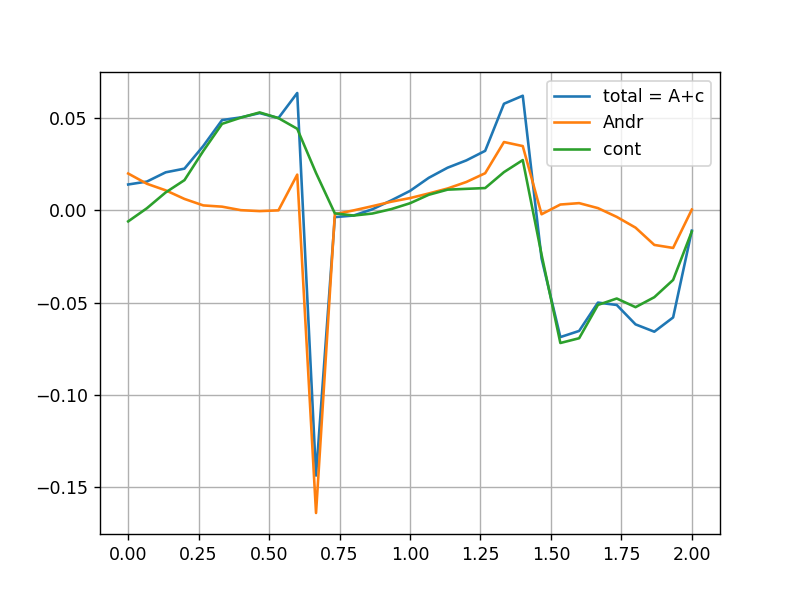

In [187]:
plt.plot(phi_0/np.pi, I, label='total = A+c')
plt.plot(phi_0/np.pi, I_A, label='Andr')
plt.plot(phi_0/np.pi, I_cont, label='cont')

plt.grid()
plt.legend()

In [93]:
I_pl = np.max(I)
I_min = np.max(-I)

eta = np.abs(I_pl - I_min)/(I_pl + I_min)
print('eta = ', eta*100, "%")

eta =  12.919545468731977 %


In [94]:
I_A_pl = np.max(I_A)
I_A_min = np.max(-I_A)

eta_A = np.abs(I_A_pl - I_A_min)/(I_A_pl + I_A_min)
print('eta_A = ', eta_A*100, "%")

eta_A =  43.072593841036976 %
